🧠 Perguntas que seu código em Python deve responder:

Quais categorias tiveram crescimento ou queda nas vendas nos últimos meses?

Existe uma correlação negativa entre aumento de preço e quantidade vendida?

Quais regiões estão mais sensíveis à variação de preço?

In [23]:
import pandas as pd 

df_produtos = pd.read_csv('../data/produtos.csv')
df_vendas = pd.read_csv('../data/vendas.csv')
df_produtos

,id_produto,nome_produto,categoria
0,P001,Produto 1,Elétrica
1,P002,Produto 2,Motor
2,P003,Produto 3,Freios
3,P004,Produto 4,Freios
4,P005,Produto 5,Motor
5,P006,Produto 6,Elétrica
6,P007,Produto 7,Elétrica
7,P008,Produto 8,Suspensão
8,P009,Produto 9,Suspensão
9,P010,Produto 10,Elétrica


In [21]:
df_vendas['total_vendido'] = df_vendas['quantidade_vendida'] * df_vendas['preco_unitario']
df_vendas

,data,id_produto,quantidade_vendida,preco_unitario,regiao,total_vendido
0,2024-01-07,P016,16,290.15,Centro-Oeste,4642.40
1,2024-01-07,P011,10,545.93,Sul,5459.30
2,2024-01-07,P020,17,222.17,Sul,3776.89
3,2024-01-07,P008,18,61.78,Norte,1112.04
4,2024-01-07,P010,20,162.39,Centro-Oeste,3247.80
...,...,...,...,...,...,...
1555,2024-12-29,P005,12,428.29,Centro-Oeste,5139.48
1556,2024-12-29,P013,7,471.81,Nordeste,3302.67
1557,2024-12-29,P008,15,673.43,Sul,10101.45
1558,2024-12-29,P015,10,479.56,Sul,4795.60


In [24]:
df_vendas = pd.merge(df_vendas,df_produtos,on='id_produto',how='left')
df_vendas

,data,id_produto,quantidade_vendida,preco_unitario,regiao,nome_produto,categoria
0,2024-01-07,P016,16,290.15,Centro-Oeste,Produto 16,Elétrica
1,2024-01-07,P011,10,545.93,Sul,Produto 11,Motor
2,2024-01-07,P020,17,222.17,Sul,Produto 20,Freios
3,2024-01-07,P008,18,61.78,Norte,Produto 8,Suspensão
4,2024-01-07,P010,20,162.39,Centro-Oeste,Produto 10,Elétrica
...,...,...,...,...,...,...,...
1555,2024-12-29,P005,12,428.29,Centro-Oeste,Produto 5,Motor
1556,2024-12-29,P013,7,471.81,Nordeste,Produto 13,Motor
1557,2024-12-29,P008,15,673.43,Sul,Produto 8,Suspensão
1558,2024-12-29,P015,10,479.56,Sul,Produto 15,Freios


In [172]:
df_vendas['total_vendido'] = df_vendas['quantidade_vendida'] * df_vendas['preco_unitario']
vendas_por_categoria_e_mes = pd.DataFrame((
    df_vendas
    .groupby(['categoria','data'])['total_vendido']
    .sum()
    .reset_index()
))

In [179]:
pivot = vendas_por_categoria_e_mes.pivot(index='categoria',columns='data',values='total_vendido')
pivot

data,2024-01-07,2024-01-14,2024-01-21,2024-01-28,2024-02-04,2024-02-11,2024-02-18,2024-02-25,2024-03-03,2024-03-10,...,2024-10-27,2024-11-03,2024-11-10,2024-11-17,2024-11-24,2024-12-01,2024-12-08,2024-12-15,2024-12-22,2024-12-29
categoria,,,,,,,,,,,,,,,,,,,,,
Elétrica,34350.22,40847.86,22892.45,32103.42,22568.01,15146.89,32016.97,14321.90,38153.99,43148.49,...,19591.70,47884.28,53232.53,14148.30,49465.62,47373.35,18455.94,16869.29,15463.87,11704.53
Freios,30973.94,52274.52,36154.25,28806.28,26234.93,61295.01,30799.81,18391.12,9905.11,33385.61,...,54109.45,23502.22,33354.94,15146.08,29247.54,27383.48,39572.74,29336.33,43040.26,22043.06
Motor,16430.76,36303.96,22531.87,45310.57,16428.48,33592.29,44918.40,70748.72,27252.77,11215.58,...,39412.40,40364.68,36272.69,48704.73,40298.56,37267.20,33266.48,21436.49,37351.98,41389.00
Suspensão,34718.07,15533.90,48311.19,31915.81,26935.66,14730.82,25787.13,53507.44,50257.72,38599.49,...,32383.76,28558.87,29926.70,54520.77,48517.49,32844.29,33982.40,40143.05,40757.80,58107.41


In [180]:
vendas_por_categoria_e_mes['total_vendido'] = pd.to_numeric(vendas_por_categoria_e_mes['total_vendido'],errors='coerce')
# vendas_por_categoria_e_mes['data'] = pd.to_datetime(vendas_por_categoria_e_mes['data'])
vendas_por_categoria_e_mes['data'] = pd.to_datetime(vendas_por_categoria_e_mes['data']).dt.to_period('M').dt.to_timestamp()
vendas_por_categoria_e_mes.dtypes


categoria                object
data             datetime64[ns]
total_vendido           float64
dtype: object

c:\Users\julia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\julia\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


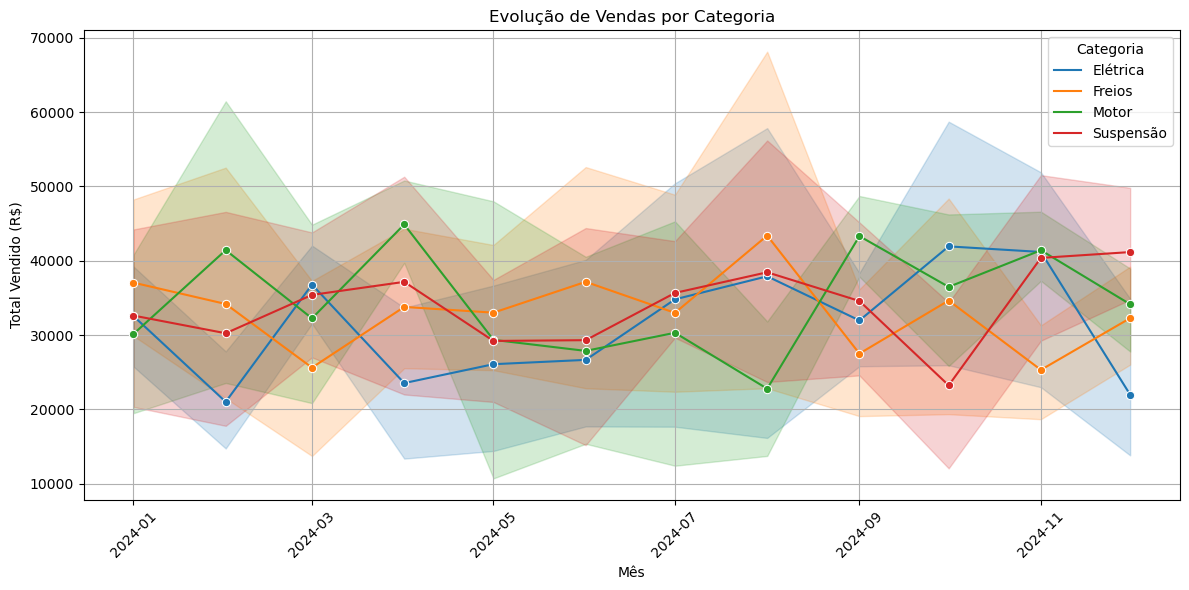

In [182]:
import seaborn as sns
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,6))
sns.lineplot(
    data=vendas_por_categoria_e_mes,
    x='data',
    y='total_vendido',
    hue='categoria',
    marker='o'
)
plt.title('Evolução de Vendas por Categoria')
plt.xlabel('Mês')
plt.ylabel('Total Vendido (R$)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title='Categoria')
plt.show()